# Tarea 1 – Perfil Demográfico y Panorama de Migración
**Curso:** IELE756 – Preparación y Análisis de Datos  
**Grupo:** Sofía Fariña, Martina Retamales.
**Comunas asignadas:** Peñalolen, Peñaflor
**Fecha:** 24 de marzo del  2026  

## Objectivo
Construir un perfil demográfico y de migración de comunas usando datos del Censo 2024

## Parte 0: Carga y unión de datos

En esta sección se cargaron las tablas de vivienda, hogar y persona del Censo 2024 seleccionando únicamente las variables necesarias para el análisis, con el fin de reducir uso de memoria. Luego se filtró la tabla de viviendas a las comunas asignadas mediante codigo_comuna, y ese subconjunto se usó para filtrar hogares y personas a través de id_vivienda. Finalmente, se realizó un join entre personas, hogares y viviendas, verificando que el número de filas finales coincidiera con el número de registros de personas filtradas.

In [1]:
import pandas as pd
from pathlib import Path
#rutas
DATA_DIR = Path("data")
vivienda_path = "/content/viviendas_censo2024.parquet"
hogar_path ="/content/hogares_censo2024.parquet"
persona_path = "/content/personas_censo2024.parquet"

In [2]:
cols_vivienda = ["id_vivienda", "region", "comuna", "tipo_operativo", "p2_tipo_vivienda", "p4a_mat_paredes", "p4b_mat_techo", "p4c_mat_piso", 'indice_hacinamiento']
cols_hogar = ["id_vivienda", "id_hogar","p12_tenencia_viv", "tipologia_hogar"]
cols_persona = ["id_vivienda", "id_hogar", "id_persona","sexo", "edad","parentesco",
    "p27_nacionalidad","p27_nacionalidad_esp", "p27_nacionalidad_rec","p24_lug_resid5","p24_lug_resid5_esp", "p25_lug_nacimiento", "p26_llegada_periodo",
    "escolaridad", "cine11", "sit_fuerza_trabajo","cod_ciuo", "cod_caenes", "p45_medio_transporte"]

vivienda = pd.read_parquet(vivienda_path, columns=cols_vivienda)
hogar = pd.read_parquet(hogar_path, columns=cols_hogar)
persona = pd.read_parquet(persona_path, columns=cols_persona)

print("=== Tablas originales ===")
print("Vivienda:", vivienda.shape)
print("Hogar:", hogar.shape)
print("Persona:", persona.shape)

=== Tablas originales ===
Vivienda: (7664466, 9)
Hogar: (6622597, 4)
Persona: (18480432, 19)


In [3]:
# Según el diccionario de los códigos de cada comuna. Peñalolen y Peñaflor son los siguientes:
COMUNAS = [13122, 13605]

viv = vivienda[vivienda["comuna"].isin(COMUNAS)].copy()
hog = hogar[hogar["id_vivienda"].isin(viv["id_vivienda"])].copy()
per = persona[persona["id_vivienda"].isin(viv["id_vivienda"])].copy()

print("\n=== Tablas filtradas ===")
print("Filas vivienda filtrada:", len(viv))
print("Filas hogar filtrada:", len(hog))
print("Filas persona filtrada:", len(per))

#unir y validar
df = (per.merge(hog, on=["id_vivienda", "id_hogar"], how="left").merge(viv, on="id_vivienda", how="left"))
assert len(df) == len(per), "Row count mismatch after join!"

print("\n=== DataFrame final ===")
print("Shape final:", df.shape)
df.info()


=== Tablas filtradas ===
Filas vivienda filtrada: 108845
Filas hogar filtrada: 107126
Filas persona filtrada: 330880

=== DataFrame final ===
Shape final: (330880, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330880 entries, 0 to 330879
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id_vivienda           330880 non-null  int32  
 1   id_hogar              330880 non-null  int32  
 2   id_persona            330880 non-null  int32  
 3   sexo                  330880 non-null  int32  
 4   edad                  330880 non-null  int32  
 5   parentesco            330880 non-null  int32  
 6   p27_nacionalidad      330880 non-null  int32  
 7   p27_nacionalidad_esp  330880 non-null  int32  
 8   p27_nacionalidad_rec  330880 non-null  int32  
 9   p24_lug_resid5        330880 non-null  int32  
 10  p24_lug_resid5_esp    316749 non-null  float64
 11  p25_lug_nacimiento    330880 non-null  

Finalmente, se verificó que no se perdieran observaciones en el proceso de merge, asegurando la consistencia de los datos y dejando el conjunto listo para el análisis posterior.

## Parte 1.1: Pirámide poblacional

En esta sección se construye una pirámide poblacional diferenciando la población por sexo y por condición de nacionalidad/ origen, con el fin de comparar la estructura etaria de personas nacidas en Chile y personas extranjeras. Para ello, primero se eliminan edades faltantes codificadas como -99, luego se crean grupos de edad y finalmente se grafica la distribución por sexo, destacando visualmente el subconjunto extranjero sobre la población total.

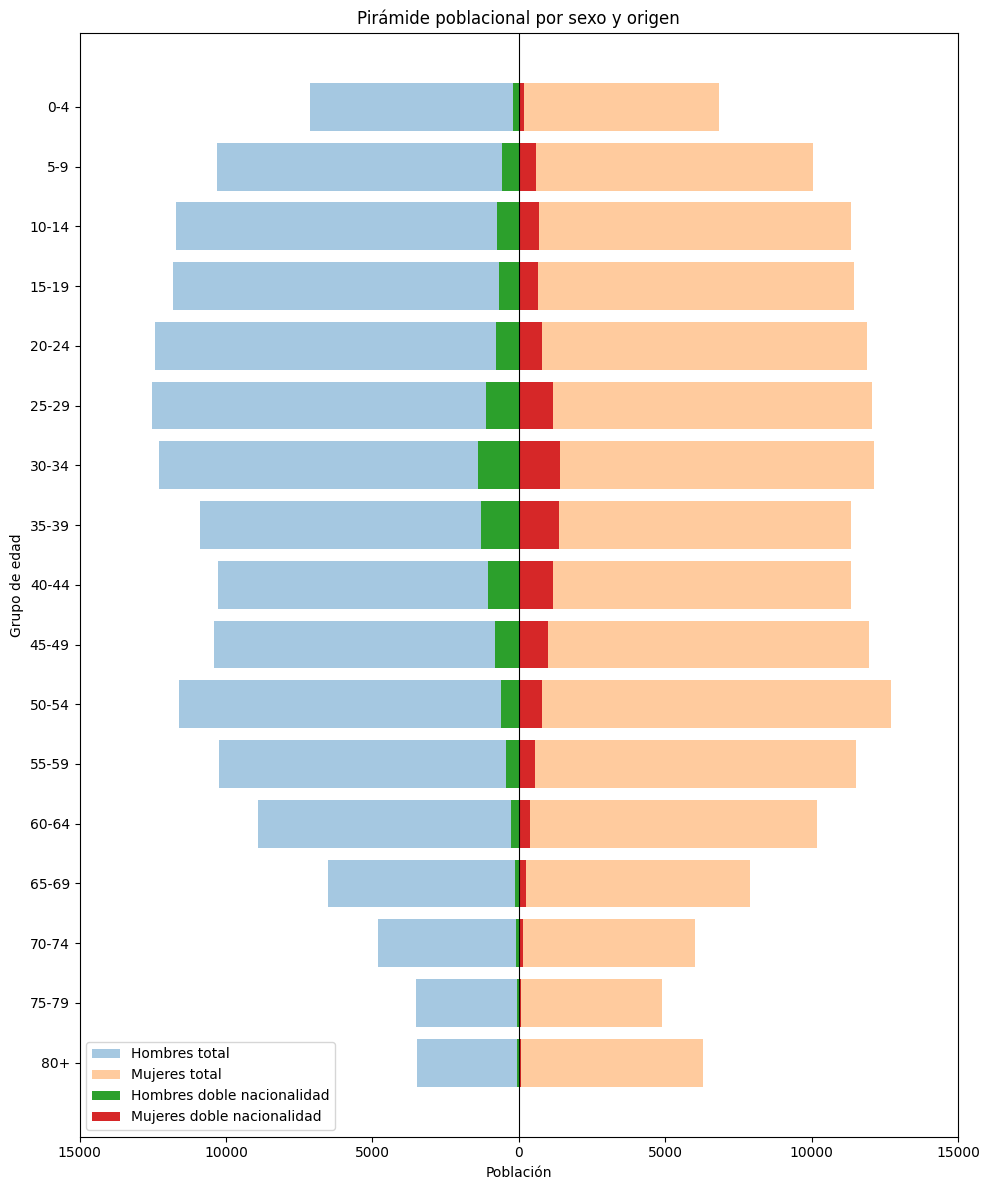

In [4]:
#no usamos los datos con -99
df_pir = df[(df["edad"] != -99) & (df["p27_nacionalidad_rec"] != -99)].copy()

# Cambiar nombres para facilitar comprensión
df_pir["origen"] = df_pir["p27_nacionalidad_rec"].map({1: "Chileno",2: "Doble nacionalidad"})

# Crear grupos de edad
bins = list(range(0, 81, 5)) + [200]
labels = [f"{i}-{i+4}" for i in range(0, 80, 5)] + ["80+"]
df_pir["grupo_edad"] = pd.cut(df_pir["edad"],bins=bins,labels=labels,right=False)

# Pirámide
piramide = (df_pir.groupby(["grupo_edad", "sexo"], observed=False).size().unstack(fill_value=0))
piramide = piramide.rename(columns={1: "Hombres", 2: "Mujeres"}) #cambio de nomrbe

# Subgrupo: doble nacionalidad (como se pide)
df_ext = df_pir[df_pir["origen"] == "Doble nacionalidad"].copy()
piramide_ext = (df_ext.groupby(["grupo_edad", "sexo"], observed=False).size().unstack(fill_value=0))
piramide_ext = piramide_ext.rename(columns={1: "Hombres", 2: "Mujeres"})

# Asegurar que existan ambas columnas
for col in ["Hombres", "Mujeres"]:
    if col not in piramide.columns:
        piramide[col] = 0
    if col not in piramide_ext.columns:
        piramide_ext[col] = 0

# Invertir hombres para el grafico
piramide["Hombres"] = -piramide["Hombres"]
piramide_ext["Hombres"] = -piramide_ext["Hombres"]

# Ordenar edades
piramide = piramide.sort_index(ascending=False)
piramide_ext = piramide_ext.reindex(piramide.index, fill_value=0)

# Graficar
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 12))
plt.barh(piramide.index,piramide["Hombres"],alpha=0.4,label="Hombres total")
plt.barh(piramide.index,piramide["Mujeres"],alpha=0.4,label="Mujeres total")
# doble nacionalidad
plt.barh(piramide_ext.index,piramide_ext["Hombres"],label="Hombres doble nacionalidad")
plt.barh(piramide_ext.index,piramide_ext["Mujeres"],label="Mujeres doble nacionalidad")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Población")
plt.ylabel("Grupo de edad")
plt.title("Pirámide poblacional por sexo y origen")
ticks = plt.xticks()[0]
plt.xticks(ticks, [abs(int(t)) for t in ticks])
plt.legend()
plt.tight_layout()
plt.show()
plt.show()

La pirámide poblacional muestra una distribución relativamente equilibrada entre hombres y mujeres en la mayoría de los grupos de edad. La población con doble nacionalidad se concentra principalmente en edades entre los 25 y 44 años, lo que sugiere una mayor presencia en edades económicamente activas. En contraste, su participación es menor en edades extremas, tanto en la infancia como en edades avanzadas.

In [5]:
print("=== VERIFICACIÓN GENERAL ===")
print("Edades -99 en df_pir:", (df_pir["edad"] == -99).sum())
print("p27_nacionalidad_rec = -99 en df_pir:", (df_pir["p27_nacionalidad_rec"] == -99).sum())
print("\nGrupos de edad creados:")
print(df_pir["grupo_edad"].value_counts(dropna=False).sort_index())
print("\nSuma pirámide total:")
print("Hombres total:", abs(piramide["Hombres"]).sum())
print("Mujeres total:", piramide["Mujeres"].sum())
check_hombres = (abs(piramide_ext["Hombres"]) <= abs(piramide["Hombres"])).all()
check_mujeres = (piramide_ext["Mujeres"] <= piramide["Mujeres"]).all()
print("\n¿Doble nacionalidad <= total en todos los grupos?")
print("Hombres:", check_hombres)
print("Mujeres:", check_mujeres)

=== VERIFICACIÓN GENERAL ===
Edades -99 en df_pir: 0
p27_nacionalidad_rec = -99 en df_pir: 0

Grupos de edad creados:
grupo_edad
0-4      13969
5-9      20345
10-14    23061
15-19    23271
20-24    24317
25-29    24594
30-34    24396
35-39    22240
40-44    21631
45-49    22366
50-54    24343
55-59    21767
60-64    19088
65-69    14402
70-74    10838
75-79     8401
80+       9790
Name: count, dtype: int64

Suma pirámide total:
Hombres total: 158847
Mujeres total: 169972

¿Doble nacionalidad <= total en todos los grupos?
Hombres: True
Mujeres: True


## Paso 1.2: Índice de dependencia por edad

In [6]:
#creamos nuevo df con el datos limpios
df_dep = df[df["edad"] != -66].copy()
#grupos de edad pedidos
df_dep["grupo_dep"] = pd.cut(df_dep["edad"],bins=[0, 15, 65, 200],labels=["0-14", "15-64", "65+"],right=False)

#agrupar por comuna
tabla_dep = (df_dep.groupby(["comuna", "grupo_dep"], observed=False).size().unstack(fill_value=0))
#ratio
tabla_dep["dependency_ratio"] = ((tabla_dep["0-14"] + tabla_dep["65+"]) / tabla_dep["15-64"])
resultado = tabla_dep[["0-14", "15-64", "65+", "dependency_ratio"]]
resultado

grupo_dep,0-14,15-64,65+,dependency_ratio
comuna,,,,
13122,40122,164801,31555,0.434931
13605,17745,64609,12048,0.461128


Ambos valores indican que por cada persona en edad de trabajar (15-64 años), hay aproximadamente entre 0.43 y 0.46 personas dependientes (menores de 15 años o mayores de 65 años).
Tras observar los resultados, esperaba un mayor indice de dependencia pero se encuentra en un rango esperado. Teneniendo en cuenta las comunas evaluadas y las edades extremas ya que presentan mucha población.

## Parte 1.3: Distribución del tamaño del hogar

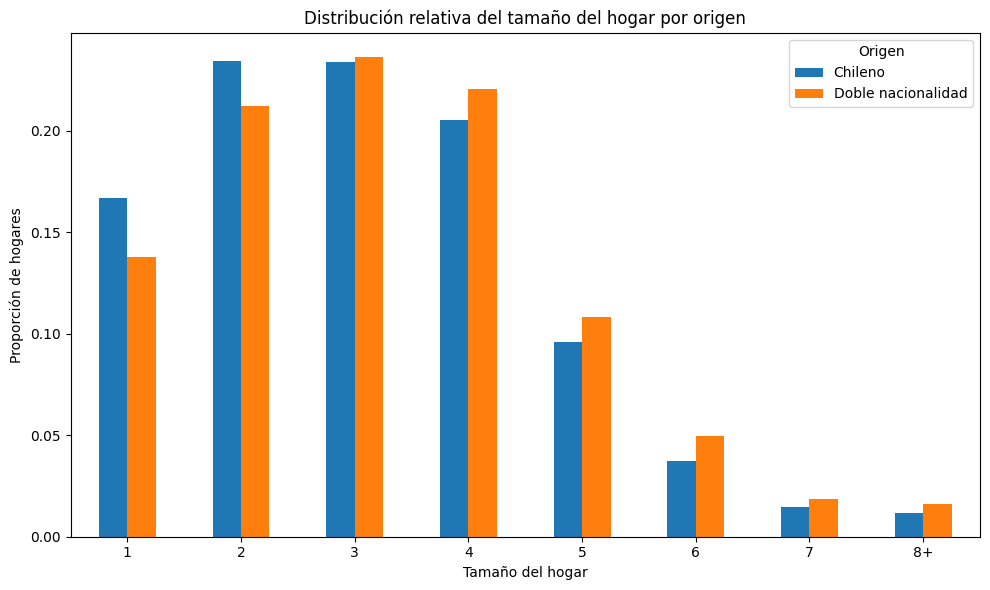

In [7]:
#contamos personas por hogar
hogar_size = (df.groupby(["id_vivienda", "id_hogar"]).size().reset_index(name="tamano_hogar"))

#identificar las nacionalidad
hogar_nac = (df.groupby(["id_vivienda", "id_hogar"])["p27_nacionalidad_rec"].max().reset_index())

#unir
hogar_size = hogar_size.merge(hogar_nac,on=["id_vivienda", "id_hogar"],how="left")
hogar_size["origen"] = hogar_size["p27_nacionalidad_rec"].map({1: "Chileno",2: "Doble nacionalidad"})

#tamaño y distribucion
hogar_size["tamano_cat"] = hogar_size["tamano_hogar"].apply(lambda x: str(x) if x < 8 else "8+")
dist = (hogar_size.groupby(["tamano_cat", "origen"]).size().unstack(fill_value=0))
orden = [str(i) for i in range(1, 8)] + ["8+"]
dist = dist.reindex(orden)

import matplotlib.pyplot as plt
dist_prop = dist.div(dist.sum(axis=0), axis=1)
dist_prop.plot(kind="bar", figsize=(10, 6))
plt.xlabel("Tamaño del hogar")
plt.ylabel("Proporción de hogares")
plt.title("Distribución relativa del tamaño del hogar por origen")
plt.xticks(rotation=0)
plt.legend(title="Origen")
plt.tight_layout()
plt.show()

Al analizar la distribución del tamaño del hogar, se observan diferencias claras entre ambos grupos. Los hogares exclusivamente chilenos presentan una mayor proporción de hogares pequeños. En contraste, los hogares con doble nacionalidad tienden a concentrarse en tamaños más grandes, hogares de 3 a 5 personas y superiores. Esto sugiere diferencias en la estructura familiar, donde los hogares con doble nacionalidad son, en promedio, más numerosos.


## Part 1.4: Educación y empleo

In [8]:
#copiamos df hecho antes
df_edu = df_pir.copy()
df_esc = df_edu[(df_edu["edad"] >= 25) & (~df_edu["escolaridad"].isin([-99, -66]))& (~df_edu["edad"].isin([-99, -66]))].copy()
#agupamos y calculamos promedio
edu_res = (df_esc.groupby(["comuna", "origen"], observed=False)["escolaridad"].mean().reset_index().rename(columns={"escolaridad": "promedio_escolaridad"}))

df_emp = df_edu[(df_edu["edad"] >= 15) &(df_edu["edad"] <= 64) &(df_edu["sit_fuerza_trabajo"].notna()) &(~df_edu["sit_fuerza_trabajo"].isin([-99, -66]))].copy()

# 1 = ocupado
df_emp["empleado"] = (df_emp["sit_fuerza_trabajo"] == 1).astype(int)
#tasa de empleo
emp_res = (df_emp.groupby(["comuna", "origen"], observed=False)["empleado"].mean().reset_index().rename(columns={"empleado": "tasa_empleo"}))
# a porcentaje
emp_res["tasa_empleo"] = emp_res["tasa_empleo"] * 100
final_res = emp_res.merge(edu_res, on=["comuna", "origen"], how="left")
final_res["tasa_empleo"] = final_res["tasa_empleo"].round(2)
final_res["promedio_escolaridad"] = final_res["promedio_escolaridad"].round(2)
final_res

,comuna,origen,tasa_empleo,promedio_escolaridad
0,13122,Chileno,64.72,12.22
1,13122,Doble nacionalidad,77.57,12.85
2,13605,Chileno,59.74,11.98
3,13605,Doble nacionalidad,70.51,12.99


Con estos resultados, se observa una gran diferencia entre chileno y doble nacionalidad. Para verificar los datos, genero lo siguiente:

In [9]:
#chequear y comparar segunda rango de edad y origen
df_esc_check = df_edu[(df_edu["edad"] >= 25) &(~df_edu["escolaridad"].isin([-99, -66]))].copy()
bins = [25, 35, 45, 55, 65, 100]
labels = ["25-34", "35-44", "45-54", "55-64", "65+"]
df_esc_check["grupo_edad"] = pd.cut(df_esc_check["edad"], bins=bins, labels=labels)
check_edu = (df_esc_check.groupby(["grupo_edad", "origen"])["escolaridad"].mean().reset_index())
check_edu

/tmp/ipykernel_5699/3406480196.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  check_edu = (df_esc_check.groupby(["grupo_edad", "origen"])["escolaridad"].mean().reset_index())


,grupo_edad,origen,escolaridad
0,25-34,Chileno,13.789755
1,25-34,Doble nacionalidad,13.070610
2,35-44,Chileno,13.618221
3,35-44,Doble nacionalidad,13.207154
4,45-54,Chileno,12.757940
5,45-54,Doble nacionalidad,12.652073
6,55-64,Chileno,11.355547
7,55-64,Doble nacionalidad,12.230976
8,65+,Chileno,8.777518
9,65+,Doble nacionalidad,11.629530


Se observa que los primeros grupos de edad, ambos tienen un promedio similar de escolaridad pero desde el grupo 6 [55- 65+ años] las personas con doble nacionalidad de ambas comunas evaluadas, tienen en promedio mayor escolaridad.

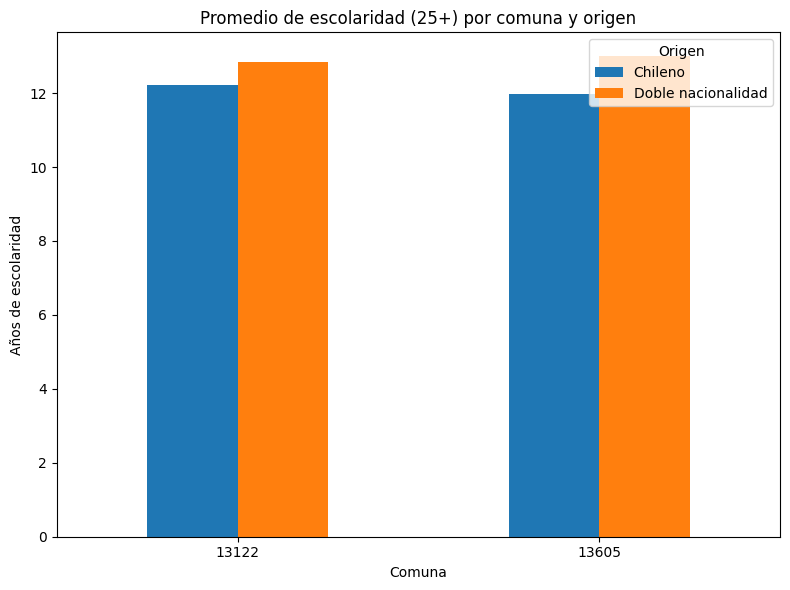

In [10]:
#Gráfico 1: escolaridad
edu_plot = edu_res.pivot(index="comuna", columns="origen", values="promedio_escolaridad")
edu_plot.plot(kind="bar", figsize=(8,6))
plt.title("Promedio de escolaridad (25+) por comuna y origen")
plt.xlabel("Comuna")
plt.ylabel("Años de escolaridad")
plt.xticks(rotation=0)
plt.legend(title="Origen")
plt.tight_layout()
plt.show()

Observado los resultados anteriores y el gráfico, podemos observar que en ambas comunas la población con doble nacionalidad tiene un mayor promedio de años escolares que los chilenos. Esta diferencia se observa principalmente en las personas con 55+ de edad. Tambien podemos decir que, os chilenos, tienen ooportunidad de estudiar que los de doble nacionalidad (observado en el primer rango).

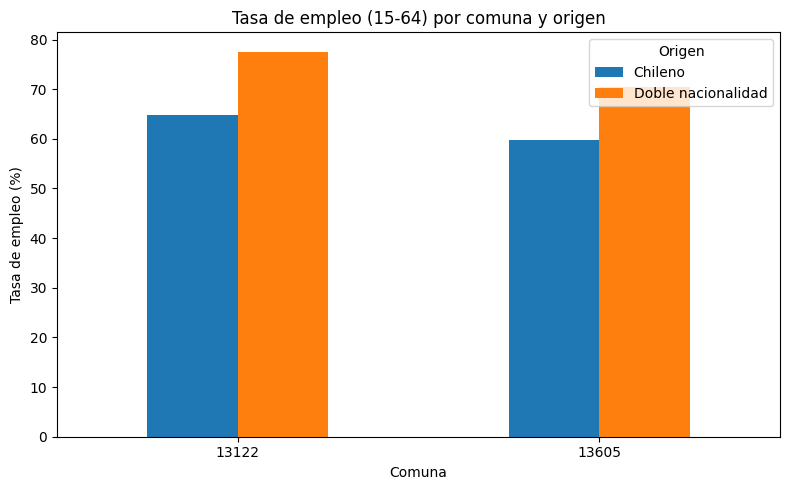

In [11]:
#Gráfico 2: empleo
emp_plot = emp_res.pivot(index="comuna", columns="origen", values="tasa_empleo")

emp_plot.plot(kind="bar", figsize=(8,5))

plt.title("Tasa de empleo (15-64) por comuna y origen")
plt.xlabel("Comuna")
plt.ylabel("Tasa de empleo (%)")
plt.xticks(rotation=0)

plt.legend(title="Origen")
plt.tight_layout()
plt.show()

In [12]:
df_emp["grupo_edad"] = pd.cut(df_emp["edad"], bins=bins, labels=labels, right=False)
check_edad = (df_emp.groupby(["grupo_edad", "origen"])["empleado"].mean().reset_index())
check_edad["empleado"] = check_edad["empleado"] * 100
check_edad

/tmp/ipykernel_5699/2448245008.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  check_edad = (df_emp.groupby(["grupo_edad", "origen"])["empleado"].mean().reset_index())


,grupo_edad,origen,empleado
0,25-34,Chileno,73.368772
1,25-34,Doble nacionalidad,81.439468
2,35-44,Chileno,79.693959
3,35-44,Doble nacionalidad,84.900635
4,45-54,Chileno,76.689360
5,45-54,Doble nacionalidad,84.984326
6,55-64,Chileno,66.013722
7,55-64,Doble nacionalidad,76.732673
8,65+,Chileno,NaN
9,65+,Doble nacionalidad,NaN


Observando el gráfico y el detalle entre grupo de edad, origen y empleado. Podemos decir que los chilenos trabajan "menos" que los de doble nacionalidad (por distintas razones tanto por lo economico, migración, dependencia, apoyo,etc). Ademas, los de doble nacionalidad cuentan con mayor tasa de empleo en todos los rangos y en ambas comunas.

## Parte 2: Panorama migratorio

,comuna,porcentaje_extranjero
0,13122,8.57
1,13605,3.98


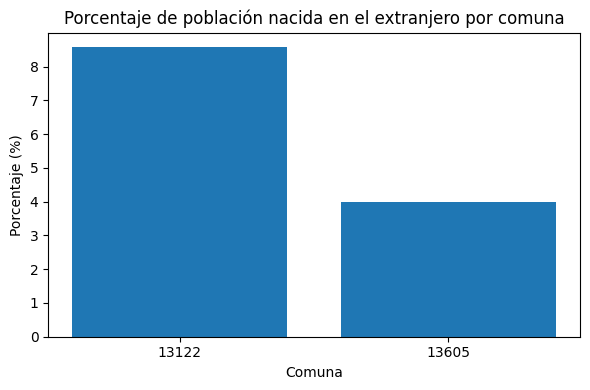

In [13]:
# usamos nueva variable p25_lug_nacimiento:  Cuándo nació, ¿en qué comuna o país vivía su madre?

df_mig = df[(~df["p25_lug_nacimiento"].isin([-99]))].copy()

# 1= nacio en la misma comuna
#2= nacio en otra comuna
#3= nacio en otro pais

df_mig["extranjero"] = (df_mig["p25_lug_nacimiento"] == 3).astype(int)

# Calcular porcentaje por comuna
mig_res = (df_mig.groupby("comuna")["extranjero"].mean().reset_index())
# pasar a porcentaje
mig_res["porcentaje_extranjero"] = mig_res["extranjero"] * 100
mig_res["porcentaje_extranjero"] = mig_res["porcentaje_extranjero"].round(2)
mig_res = mig_res.drop(columns="extranjero")
display(mig_res)

plt.figure(figsize=(6,4))
plt.bar(mig_res["comuna"].astype(str), mig_res["porcentaje_extranjero"])
plt.title("Porcentaje de población nacida en el extranjero por comuna")
plt.xlabel("Comuna")
plt.ylabel("Porcentaje (%)")
plt.tight_layout()
plt.show()

La comuna 13122 tiene una mayor presencia de población nacido en el extranjero que la comuna 13605, casi el doble en términos porcentuales.

## 2.2 Top nacionalidades

,codigo_pais,Territorio específico,cantidad
0,862,Venezuela,8178
1,604,Perú,5962
2,170,Colombia,2858
3,5,Otros países de América del Sur,1312
4,332,Haití,910
5,13,Otros países de América Central y El Caribe,608
6,32,Argentina,584
7,68,Bolivia,529
8,150,Europa,307
9,142,Asia,183


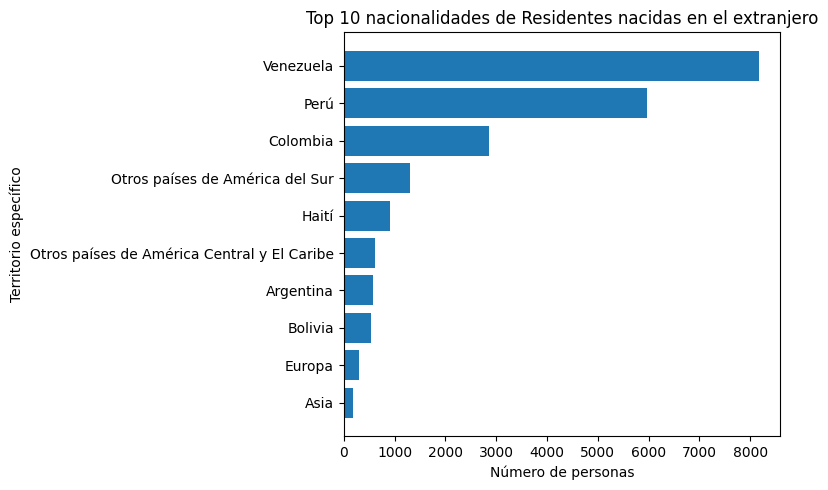

In [14]:
#nacidos en el extranjero. En las instrucciones sale que debemos usar "p27_nacionalidad" y usar su codigo para idenificar el país pero esas variables no nos da el cdoigo del país.
#Por ende, usaremos "p27_nacionalidad_esp" ya que nos entrega el codigo del pais de nacimiento.

# Solo personas nacidas en el extranjero
df_nat = df[(df["p27_nacionalidad"] == 3) &(~df["p27_nacionalidad_esp"].isin([-99, -66]))].copy()
# Top 10 nacionalidades entre nacidos en el extranjero
top_nat = (df_nat["p27_nacionalidad_esp"].value_counts().head(10).reset_index())
top_nat.columns = ["codigo_pais", "cantidad"]
#Mapa de los territorios y su codigo en el diccionario
map_paises = {
    862: "Venezuela",
    604: "Perú",
    170: "Colombia",
    5:   "Otros países de América del Sur",
    332: "Haití",
    13:  "Otros países de América Central y El Caribe",
    32:  "Argentina",
    68:  "Bolivia",
    150: "Europa",
    142: "Asia"}

top_nat["Territorio específico"] = top_nat["codigo_pais"].map(map_paises)
top_nat = top_nat[["codigo_pais", "Territorio específico", "cantidad"]]
display(top_nat)

#Gráfico
plt.figure(figsize=(8, 5))
plt.barh(top_nat["Territorio específico"], top_nat["cantidad"])
plt.title("Top 10 nacionalidades de Residentes nacidas en el extranjero")
plt.xlabel("Número de personas")
plt.ylabel("Territorio específico")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

La población nacida en el extranjero se concentra principalmente en nacionalidades latinoamericanas, destacando Venezuela, Perú y Colombia como los grupos más numerosos. En menor medida, aparecen otras nacionalidades como algunas provenientes de Europa y Asia. Esto sugiere que la migración en las comunas analizadas es mayoritariamente regional, con una fuerte presencia de países vecinos.

## 2.3 Situación migratoria: residencia hace 5 años

residencia_5anios_cat  Misma comuna  Otra comuna, misma región  Otra región  \
comuna                                                                        
13122                         84.23                      10.96         1.77   
13605                         87.00                      10.30         1.29   

residencia_5anios_cat  Abroad  
comuna                         
13122                    3.04  
13605                    1.42  


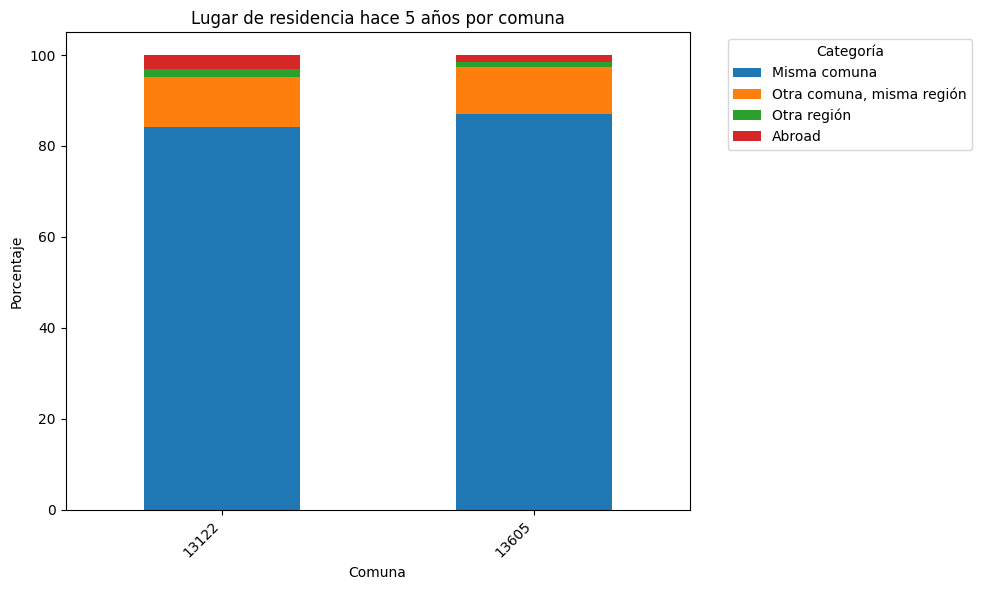

In [15]:
import numpy as np

#fitrar
mig = df.copy()
mig = mig[(mig["edad"] != -99) &(mig["edad"] >= 5) &(mig["p24_lug_resid5"] != -99)].copy()

#usamos estas variables, clasificamos para agrupar las respuestas
def clasificar(row):
    p24 = row["p24_lug_resid5"]
    esp = row["p24_lug_resid5_esp"]

    # Misma comuna
    if p24 == 2:
        return "Misma comuna"
    # Extranjero
    elif p24 == 4:
        return "Abroad"
    # Otra comuna
    elif p24 == 3:
        if esp in [-99, -66] or pd.isna(esp):
            return np.nan
        # Si es comuna de la RM (Según el diccioanrio de codigos)
        if 13101 <= esp <= 13605:
            return "Otra comuna, misma región"
        else:
            return "Otra región"
    return np.nan
mig["residencia_5anios_cat"] = mig.apply(clasificar, axis=1)

#PORCENTAJES
tabla = (mig.dropna(subset=["residencia_5anios_cat"]).groupby(["comuna", "residencia_5anios_cat"]).size().reset_index(name="n"))
tabla["pct"] = (tabla.groupby("comuna")["n"].transform(lambda x: 100 * x / x.sum()))

orden = ["Misma comuna","Otra comuna, misma región","Otra región","Abroad"]
pivot = (tabla.pivot(index="comuna", columns="residencia_5anios_cat", values="pct").fillna(0))
pivot = pivot.reindex(columns=orden, fill_value=0)
print(pivot.round(2))

# GRÁFICO
pivot.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Lugar de residencia hace 5 años por comuna")
plt.xlabel("Comuna")
plt.ylabel("Porcentaje")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Categoría", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Respuetas de las personas segun su residencia hace 5 años:

% que vivía en la misma comuna: 84.23% y 87% respectivamente.

% que vivía en una comuna diferente, en la misma región: 10.96% y 10.3%.

% que vivía en una región diferente: 1.77% y 1.29%.

% que vivía en el extranjero: 3.04% y 1.42%.

Se analizó el lugar de residencia de las personas hace cinco años utilizando las variables p24_lug_resid5 y p24_lug_resid5_esp. Primero, se filtraron los datos para excluir valores faltantes y personas menores de 5 años, ya que no eran parte de la población relevante. Luego, se construyó una variable categórica que distingue entre quienes vivían en la misma comuna, en otra comuna de la misma región (RM), en otra región del país o en el extranjero, utilizando los códigos territoriales para identificar correctamente los casos dentro de la Región Metropolitana.

Los resultados muestran que en ambas comunas la gran mayoría de la población (más del 80%) vivía en la misma comuna hace cinco años, lo que indica una baja movilidad residencial. La movilidad dentro de la misma región es el segundo fenómeno más importante, con alrededor de un 10%, mientras que la migración desde otras regiones y desde el extranjero es considerablemente menor.

## 2.4 Periodo de llegada de los inmigrantes

periodo
1990-1999         818
2000-2009        2244
2010-2013        1700
2014-2016        2637
2017-2019        6027
2020-2022        4880
2023-2024        2522
Antes de 1990     193
Name: count, dtype: int64


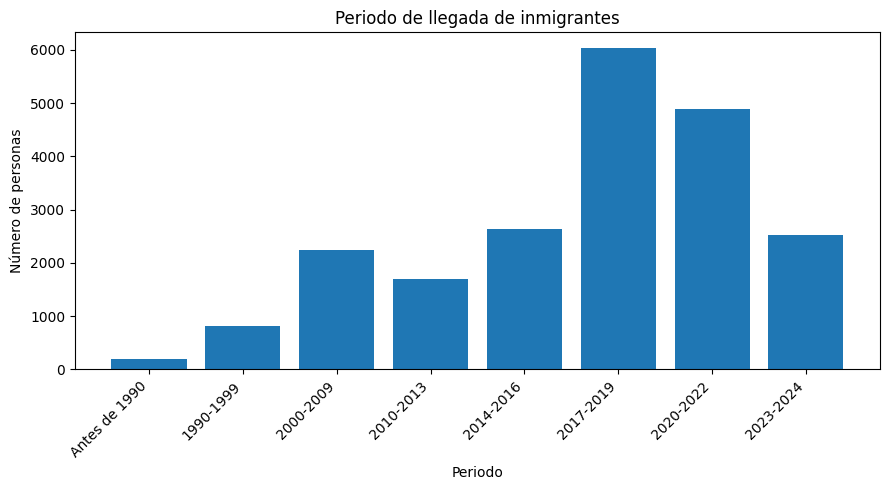

In [16]:
mig = df.copy()
#filtramos los extranjeros y que datos que no aportan
mig = mig[(mig["p27_nacionalidad_rec"] == 2) &  (mig["p26_llegada_periodo"].notna()) & (mig["p26_llegada_periodo"] != -99)    ].copy()
#En el diccionario, sale que son 8 numeros refiriendose a distintos periodos
mig = mig[mig["p26_llegada_periodo"].isin([1,2,3,4,5,6,7,8])]
map_llegada = {
    1: "2023-2024",
    2: "2020-2022",
    3: "2017-2019",
    4: "2014-2016",
    5: "2010-2013",
    6: "2000-2009",
    7: "1990-1999",
    8: "Antes de 1990"} #orden dado
mig["periodo"] = mig["p26_llegada_periodo"].map(map_llegada)
tabla = mig["periodo"].value_counts().sort_index()
print(tabla)

#orden para graáfico y ver la evolucion en el tiempo
tabla = tabla.reindex(["Antes de 1990", "1990-1999","2000-2009","2010-2013","2014-2016","2017-2019","2020-2022","2023-2024"])
plt.figure(figsize=(9,5))
plt.bar(tabla.index, tabla.values)
plt.title("Periodo de llegada de inmigrantes")
plt.xlabel("Periodo")
plt.ylabel("Número de personas")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

¿La inmigración a vuestras comunas es un fenómeno reciente o tiene una historia más larga?
Los resultados muestran que la llegada de inmigrantes a las comunas analizadas se concentra en períodos recientes, especialmente entre 2017 y 2019, seguido por 2020-2022. Esto indica que la inmigración es un fenómeno relativamente reciente y en crecimiento. En contraste, los períodos anteriores a 2000 presentan una menor cantidad de personas, lo que sugiere que la presencia de población extranjera en estas comunas ha aumentado significativamente en la última década.

## Parte 3: Visualización espacial

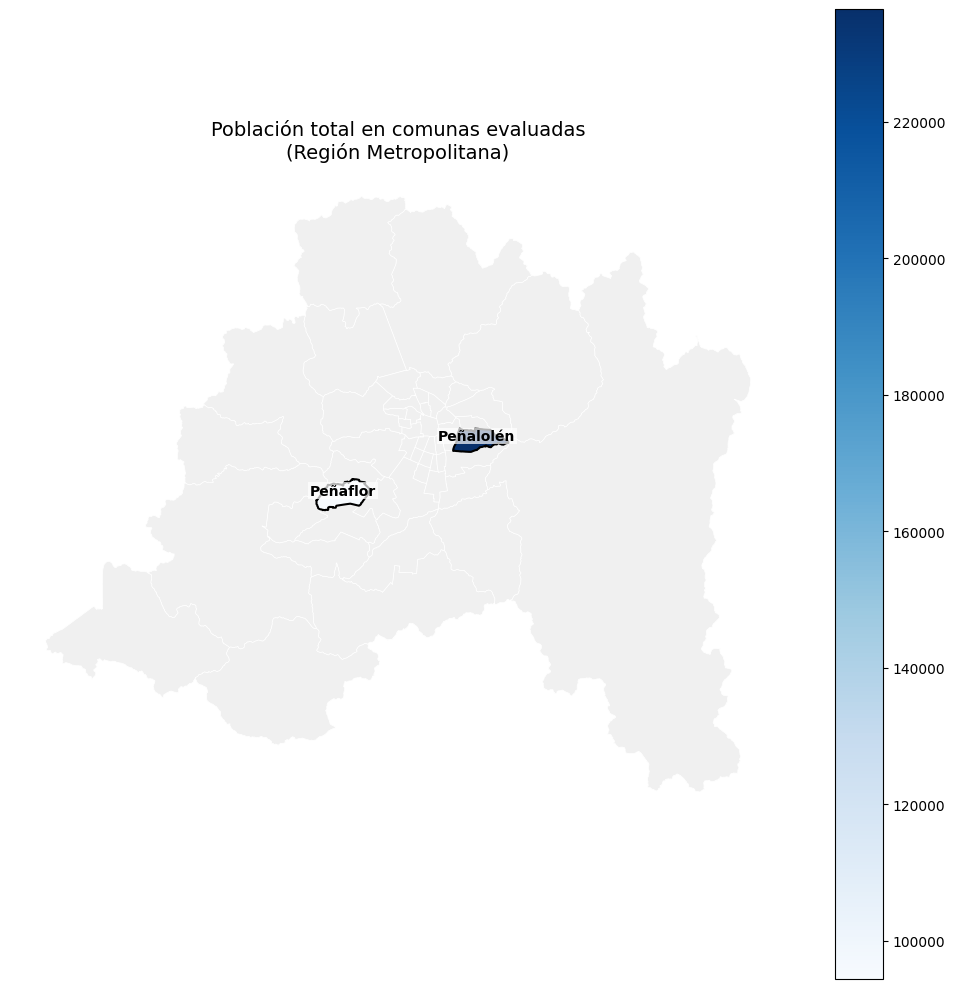

In [17]:
import os
import geopandas as gpd

# Leer shapefile dado de las comunas
comunas_gdf = gpd.read_file("comunas.shp")

# Arreglar encoding para graficar
comunas_gdf["Comuna"] = comunas_gdf["Comuna"].str.encode('latin1').str.decode('utf-8')
comunas_gdf["cod_comuna"] = comunas_gdf["cod_comuna"].astype(int)

# Filtrar RM con el nombre de comunas.shp
rm_gdf = comunas_gdf[comunas_gdf["Region"] == "RegiÃ³n Metropolitana de Santiago"].copy()

# Comunas evaluadas
COMUNAS = [13122, 13605]
comunas_eval = rm_gdf[rm_gdf["cod_comuna"].isin(COMUNAS)].copy()

# sumas poblacióm
pob_comuna = (df.groupby("comuna").size().reset_index(name="pop_total"))
pob_comuna["comuna"] = pob_comuna["comuna"].astype(int)
# Merge
comunas_eval = comunas_eval.merge(pob_comuna,left_on="cod_comuna",right_on="comuna",how="left")

# GRAFICO
fig, ax = plt.subplots(figsize=(10,10))
# Fondo RM
rm_gdf.plot(color="#f0f0f0",edgecolor="white",linewidth=0.5,ax=ax)
comunas_eval.plot(column="pop_total",cmap="Blues",legend=True,edgecolor="black",linewidth=1.5,ax=ax)
comunas_eval["centroid"] = comunas_eval.geometry.centroid

# Etiquetas
for idx, row in comunas_eval.iterrows():
    ax.annotate(
        text=row["Comuna"],
        xy=(row["centroid"].x, row["centroid"].y),
        ha="center",fontsize=10,fontweight="bold",
        color="black",bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
ax.set_title("Población total en comunas evaluadas\n(Región Metropolitana)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

In [18]:
#Verificamos calores de las columnas
df_eval = df[df["comuna"].isin(COMUNAS)]
total_eval = len(df_eval)
print("Total de personas en comunas evaluadas:", total_eval)

# Personas por comuna
pob_por_comuna = (df_eval.groupby("comuna").size().reset_index(name="pop_total").sort_values("comuna"))
print("\nPoblación por comuna:")
print(pob_por_comuna)
print("\nSuma por comunas:", pob_por_comuna["pop_total"].sum())

Total de personas en comunas evaluadas: 330880

Población por comuna:
   comuna  pop_total
0   13122     236478
1   13605      94402

Suma por comunas: 330880


Se construyó un mapa coroplético de la Región Metropolitana utilizando el shapefile de comunas y la base censal. Primero, se calculó la población total por comuna contando el número de personas en el dataset, y se verificó que estos valores fueran consistentes, comprobando que la suma por comunas coincidiera con el total de observaciones filtradas. Luego, se integraron estos datos al shapefile mediante el código de comuna.

Los resultados muestran que existe una diferencia importante en el tamaño poblacional entre las comunas analizadas, donde Peñalolén presenta una población considerablemente mayor que Peñaflor. Además, el uso del contexto espacial de toda la Región Metropolitana permite visualizar mejor la ubicación de estas comunas en la región.

## 3.2 Mapa coroplético: % de población nacida en el extranjero por comuna

   comuna  pop_total  pop_foreign  pct_foreign
0   13122     236478        18304     7.740255
1   13605      94402         3235     3.426834
   cod_comuna     Comuna  pop_total  pop_foreign  pct_foreign
0       13122  Peñalolén     236478        18304     7.740255
1       13605   Peñaflor      94402         3235     3.426834


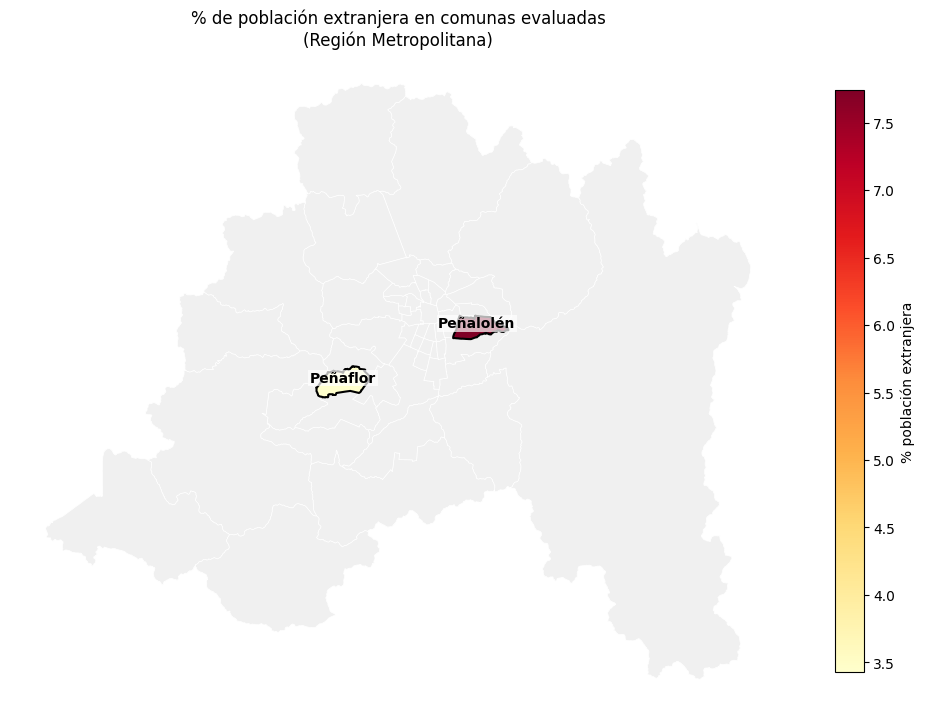

In [19]:
# resumen de población total y extranjera
resumen = (
    df[df["comuna"].isin(COMUNAS)]
    .groupby("comuna")
    .agg(pop_total=("comuna", "size"),pop_foreign=("p27_nacionalidad_rec", lambda x: (x == 2).sum())).reset_index())
resumen["pct_foreign"] = 100 * resumen["pop_foreign"] / resumen["pop_total"]
print(resumen)

# unir al mapa solo con columnas necesarias
mapa_foreign = comunas_eval[["cod_comuna", "Comuna", "geometry"]].merge(resumen,left_on="cod_comuna",right_on="comuna",how="left")
print(mapa_foreign[["cod_comuna", "Comuna", "pop_total", "pop_foreign", "pct_foreign"]])

# graficar
fig, ax = plt.subplots(figsize=(10, 10))
rm_gdf.plot(color="#f0f0f0", edgecolor="white", linewidth=0.5, ax=ax)
mapa_foreign.plot(column="pct_foreign",cmap="YlOrRd",legend=True,
    legend_kwds={'label': "% población extranjera", 'shrink': 0.6},edgecolor="black",linewidth=1.5,ax=ax)
for _, row in mapa_foreign.iterrows():
    c = row.geometry.centroid
    ax.annotate(row["Comuna"],(c.x, c.y),ha="center",fontsize=10,
        fontweight="bold",bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1))
ax.set_title("% de población extranjera en comunas evaluadas\n(Región Metropolitana)")
ax.axis("off")
plt.tight_layout()
plt.show()

Se representa el porcentaje de población extranjera en las comunas evaluadas, calculado como la proporción entre residentes extranjeros y la población total en cada territorio. Se verificó la consistencia de los resultados mediante el conteo directo de personas en la base de datos.

Los resultados muestran que Peñalolén presenta una mayor proporción de población extranjera en comparación con Peñaflor, evidenciando diferencias en la composición demográfica entre ambas comunas.

## Parte 4: Tabla resumen a nivel de comuna

In [20]:
import pandas as pd
import numpy as np
import os

# ocupado = 1
EMPLOYED_CODE = 1

#mapa
name_map = (comunas_gdf[["cod_comuna", "Comuna"]].drop_duplicates().rename(columns={"cod_comuna": "codigo_comuna", "Comuna": "nombre_comuna"}))
if name_map["nombre_comuna"].dtype == "object":
    try:
        name_map["nombre_comuna"] = (name_map["nombre_comuna"].str.encode("latin1").str.decode("utf-8"))
    except:
        pass

def build_summary(g):
    out = {}
    codigo = int(g["comuna"].iloc[0])
    out["codigo_comuna"] = codigo
    # Población total
    out["pop_total"] = len(g)
    # Nacionalidad recodificada
    chil = g[g["p27_nacionalidad_rec"] == 1]
    foreign = g[g["p27_nacionalidad_rec"] == 2]
    out["pop_chilean"] = len(chil)
    out["pop_foreign"] = len(foreign)
    out["pct_foreign"] = 100 * out["pop_foreign"] / out["pop_total"] if out["pop_total"] > 0 else np.nan
    # Edad válida
    edad_ok = g[g["edad"] != -99].copy()
    chil_edad = chil[chil["edad"] != -99]
    foreign_edad = foreign[foreign["edad"] != -99]
    # Mediana de edad
    out["median_age_chilean"] = chil_edad["edad"].median() if len(chil_edad) > 0 else np.nan
    out["median_age_foreign"] = foreign_edad["edad"].median() if len(foreign_edad) > 0 else np.nan
    # Escolaridad válida, población 25+
    chil_school = chil[(chil["edad"] != -99) & (chil["edad"] >= 25) & (chil["escolaridad"] != -99)]
    foreign_school = foreign[(foreign["edad"] != -99) & (foreign["edad"] >= 25) & (foreign["escolaridad"] != -99)]

    out["mean_schooling_chilean"] = chil_school["escolaridad"].mean() if len(chil_school) > 0 else np.nan
    out["mean_schooling_foreign"] = foreign_school["escolaridad"].mean() if len(foreign_school) > 0 else np.nan
    out["pop_missing_nationality"] = len(g[g["p27_nacionalidad_rec"] == -99])
    # Empleo 15-64
    chil_emp = chil[(chil["edad"] != -99) &(chil["edad"] >= 15) &(chil["edad"] <= 64) &(chil["sit_fuerza_trabajo"] != -99)]
    foreign_emp = foreign[(foreign["edad"] != -99) &(foreign["edad"] >= 15) &(foreign["edad"] <= 64) &(foreign["sit_fuerza_trabajo"] != -99)]
    out["emp_rate_chilean"] = (100 * (chil_emp["sit_fuerza_trabajo"] == EMPLOYED_CODE).mean()if len(chil_emp) > 0 else np.nan)
    out["emp_rate_foreign"] = (
        100 * (foreign_emp["sit_fuerza_trabajo"] == EMPLOYED_CODE).mean()
        if len(foreign_emp) > 0 else np.nan)
    # Dependency ratio
    young = ((edad_ok["edad"] >= 0) & (edad_ok["edad"] <= 14)).sum()
    old = (edad_ok["edad"] >= 65).sum()
    working = ((edad_ok["edad"] >= 15) & (edad_ok["edad"] <= 64)).sum()
    out["dependency_ratio"] = ((young + old) / working) if working > 0 else np.nan
    return pd.Series(out)

#resumen
summary = (df[df["comuna"].isin(COMUNAS)].groupby("comuna").apply(build_summary).reset_index(drop=True))
summary = summary.merge(name_map,on="codigo_comuna",how="left")
# Reordenar columnas
summary = summary[
    [
        "codigo_comuna",
        "nombre_comuna",
        "pop_total",
        "pop_chilean",
        "pop_foreign",
        "pct_foreign",
        "median_age_chilean",
        "median_age_foreign",
        "mean_schooling_chilean",
        "mean_schooling_foreign",
        "emp_rate_chilean",
        "emp_rate_foreign","dependency_ratio"]]

#resultados exportados
os.makedirs("output", exist_ok=True)
summary.to_csv("output/tarea1_comuna_summary.csv", index=False)
summary

/tmp/ipykernel_5699/3629232480.py:57: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = (df[df["comuna"].isin(COMUNAS)].groupby("comuna").apply(build_summary).reset_index(drop=True))


,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,13122.0,Peñalolén,236478.0,216664.0,18304.0,7.740255,38.0,34.0,12.222864,12.847696,64.719587,77.567496,0.434931
1,13605.0,Peñaflor,94402.0,90616.0,3235.0,3.426834,36.0,34.0,11.981959,12.994343,59.739163,70.507440,0.461128


In [21]:
# Edad usada en medianas
print("Edad usada en cálculo (sin -99):")
print(df[df["edad"] != -99]["edad"].describe())

# Escolaridad usada (25+ y sin -99)
print("\nEscolaridad válida (25+):")
print(df[(df["edad"] >= 25) & (df["escolaridad"] != -99)]["escolaridad"].describe())

# Empleo válido (15-64 y sin -99)
print("\nDatos de empleo válidos:")
print(df[(df["edad"] >= 15) & (df["edad"] <= 64) & (df["sit_fuerza_trabajo"] != -99)]["sit_fuerza_trabajo"].value_counts())

Edad usada en cálculo (sin -99):
count    330880.000000
mean         37.980588
std          21.826511
min           0.000000
25%          20.000000
50%          37.000000
75%          55.000000
max          85.000000
Name: edad, dtype: float64

Escolaridad válida (25+):
count    223532.000000
mean         12.202629
std           4.260150
min           0.000000
25%          10.000000
50%          12.000000
75%          15.000000
max          24.000000
Name: escolaridad, dtype: float64

Datos de empleo válidos:
sit_fuerza_trabajo
1.0    146491
3.0     67262
2.0     14104
Name: count, dtype: int64


Se verificó que los valores inválidos (-99, -66 y NaN) no fueron utilizados en los cálculos de los indicadores.